In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# Set up data and initial guess

In [2]:
info = np.genfromtxt('example_data/J094932+033531_64.txt', names=True)
redshift = info['z']

hdul = fits.open('example_data/J094932+033531_id64.fits')
flux = hdul[0].data
err = 1/np.sqrt(hdul[1].data)
wavelength = hdul[2].data

param_guess = (2803, 14, 90, 0.5)

# Run the fitter and check the results

In [3]:
from model_fitter import modeling

In [4]:
fitter = modeling(wavelength, flux, err, redshift, param_guess, printresult=True)

In [5]:
fitter.mcmc()

/Users/apitts4030/Repo/linetools/linetools/spectra/xspectrum1d.py:107: UserWarning: Assuming wavelength unit is Angstroms
  warnings.warn("Assuming wavelength unit is Angstroms")
  0%|                                                       | 0/600 [00:00<?, ?it/s]/Users/apitts4030/miniconda3/envs/stenv/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████| 600/600 [00:48<00:00, 12.39it/s]

MCMC result:
 par 0 = 2803.379189318846 +0.0022056005241211096 -0.0023756343612149067
 par 1 = 14.594906535724178 +0.003781256161811797 -0.0036098935043433755
 par 2 = 114.84429565796425 +0.4002041856995646 -0.3750242774370065
 par 3 = 0.8006392334771029 +0.001184718852988098 -0.0013205372241159585


In [6]:
fitter.samples.shape

(100, 600, 4)

In [7]:
samples_burned = fitter.samples[:, fitter.burnin:, :]
samples_burned.shape

(100, 100, 4)

In [8]:
best_fit = tuple(param[0] for param in fitter.theta_percentiles)

# Inspect the Best-Fit model

In [9]:
import model_MgII

In [10]:
fwhm = model_MgII.get_fwhm_MUSE_UDF(wavelength, redshift)
restwave = wavelength / (1+redshift)

In [11]:
model_dict = model_MgII.model_MgII(best_fit, fwhm, restwave)
norm_dict = model_MgII.continuum_normalize(restwave, flux, err)

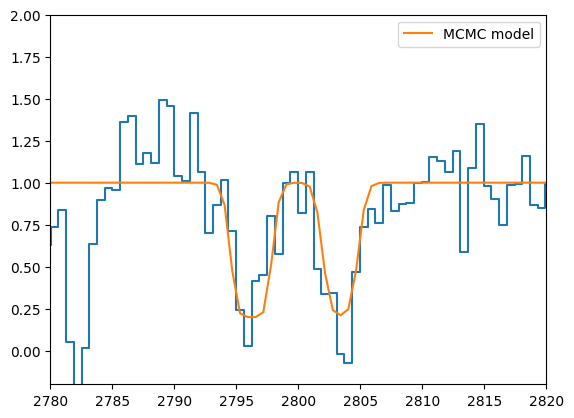

In [12]:
plt.plot(norm_dict['wavelength'], norm_dict['normflux'], drawstyle='steps-mid')
plt.plot(model_dict['modwv'], model_dict['modflx'], label='MCMC model')
plt.xlim(2780, 2820)
plt.ylim(-0.2,2)
plt.legend()